In [1]:
import abm
import numpy as np
from plotnine import *
import pandas as pd

# import and plot data

In [2]:
Tdat = pd.read_csv('inputs/Data/Data_example_subset.csv')

In [3]:
display(Tdat.head())

,dose_mpk,output,measurement,measurement_unit,time,ID,time_unit,exponential_error,dose_route
0,3.0,free_drug_p,30.167004,nM,2.333333,0,d,0.1,Dose_SC
1,3.0,free_drug_c,93.650203,nM,2.333333,0,d,0.1,Dose_SC
2,3.0,free_drug_p,29.712594,nM,4.666667,0,d,0.1,Dose_SC
3,3.0,free_drug_c,78.968045,nM,4.666667,0,d,0.1,Dose_SC
4,3.0,free_drug_p,24.398284,nM,7.000000,0,d,0.1,Dose_SC


In [4]:
def output_split(x):
    x_list = x.split('_')
    compartment = {'c':'central', 'p': 'peripheral'}
    x_list = [i if i not in compartment.keys() else compartment[i] for i in x_list]
    return ' '.join(x_list).title()

Tdat['dose_label'] = Tdat.apply(lambda x: str(x.dose_mpk) + ' mg/kg', axis = 1)
Tdat['output_label'] = Tdat.apply(lambda x: output_split(x.output), axis = 1)

# Plot data
## group by dose amount

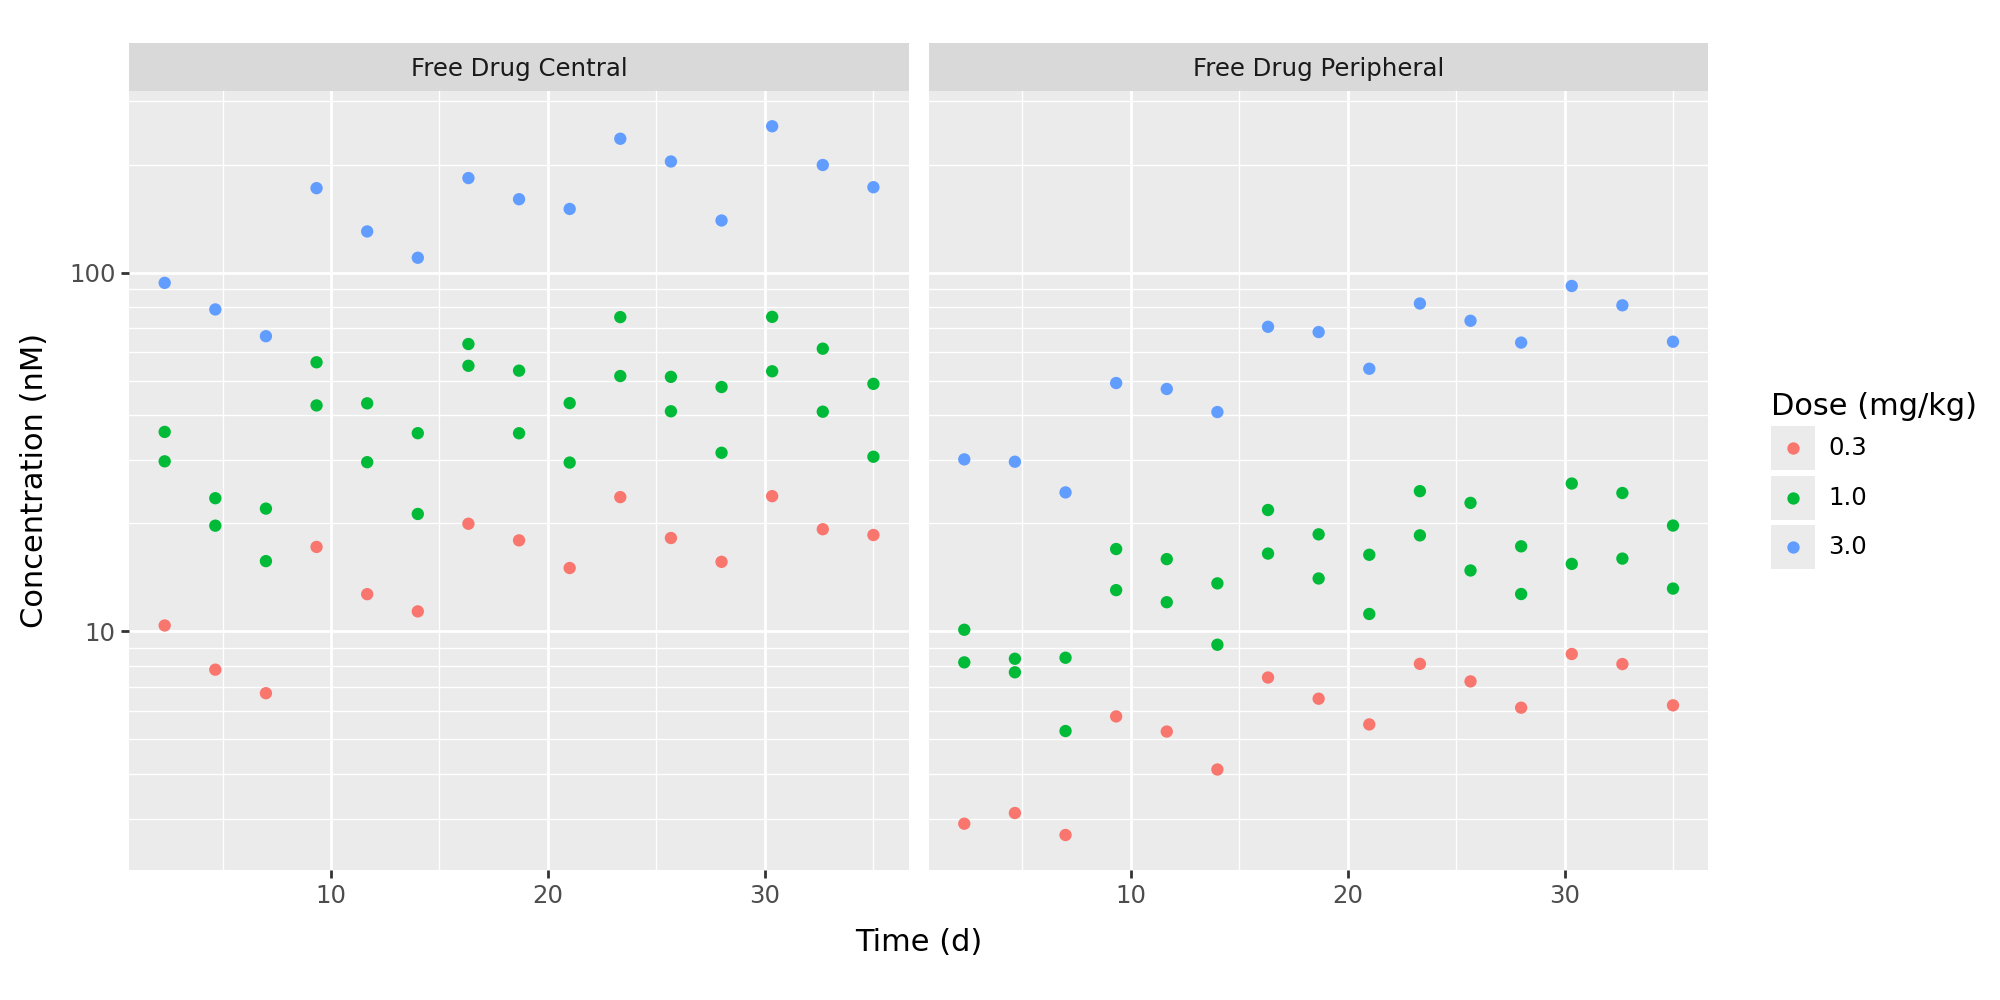

In [5]:
fig = (ggplot()
       + geom_point(data = Tdat, mapping = aes(x = 'time', y = 'measurement', color = 'factor(dose_mpk)'))
       + facet_wrap('output_label')
       + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
       + labs(y = 'Concentration (nM)', x = 'Time (d)', color = 'Dose (mg/kg)')
       + theme(aspect_ratio = 1, figure_size = (10,5))
      )

display(fig)

## Separate by patient ID

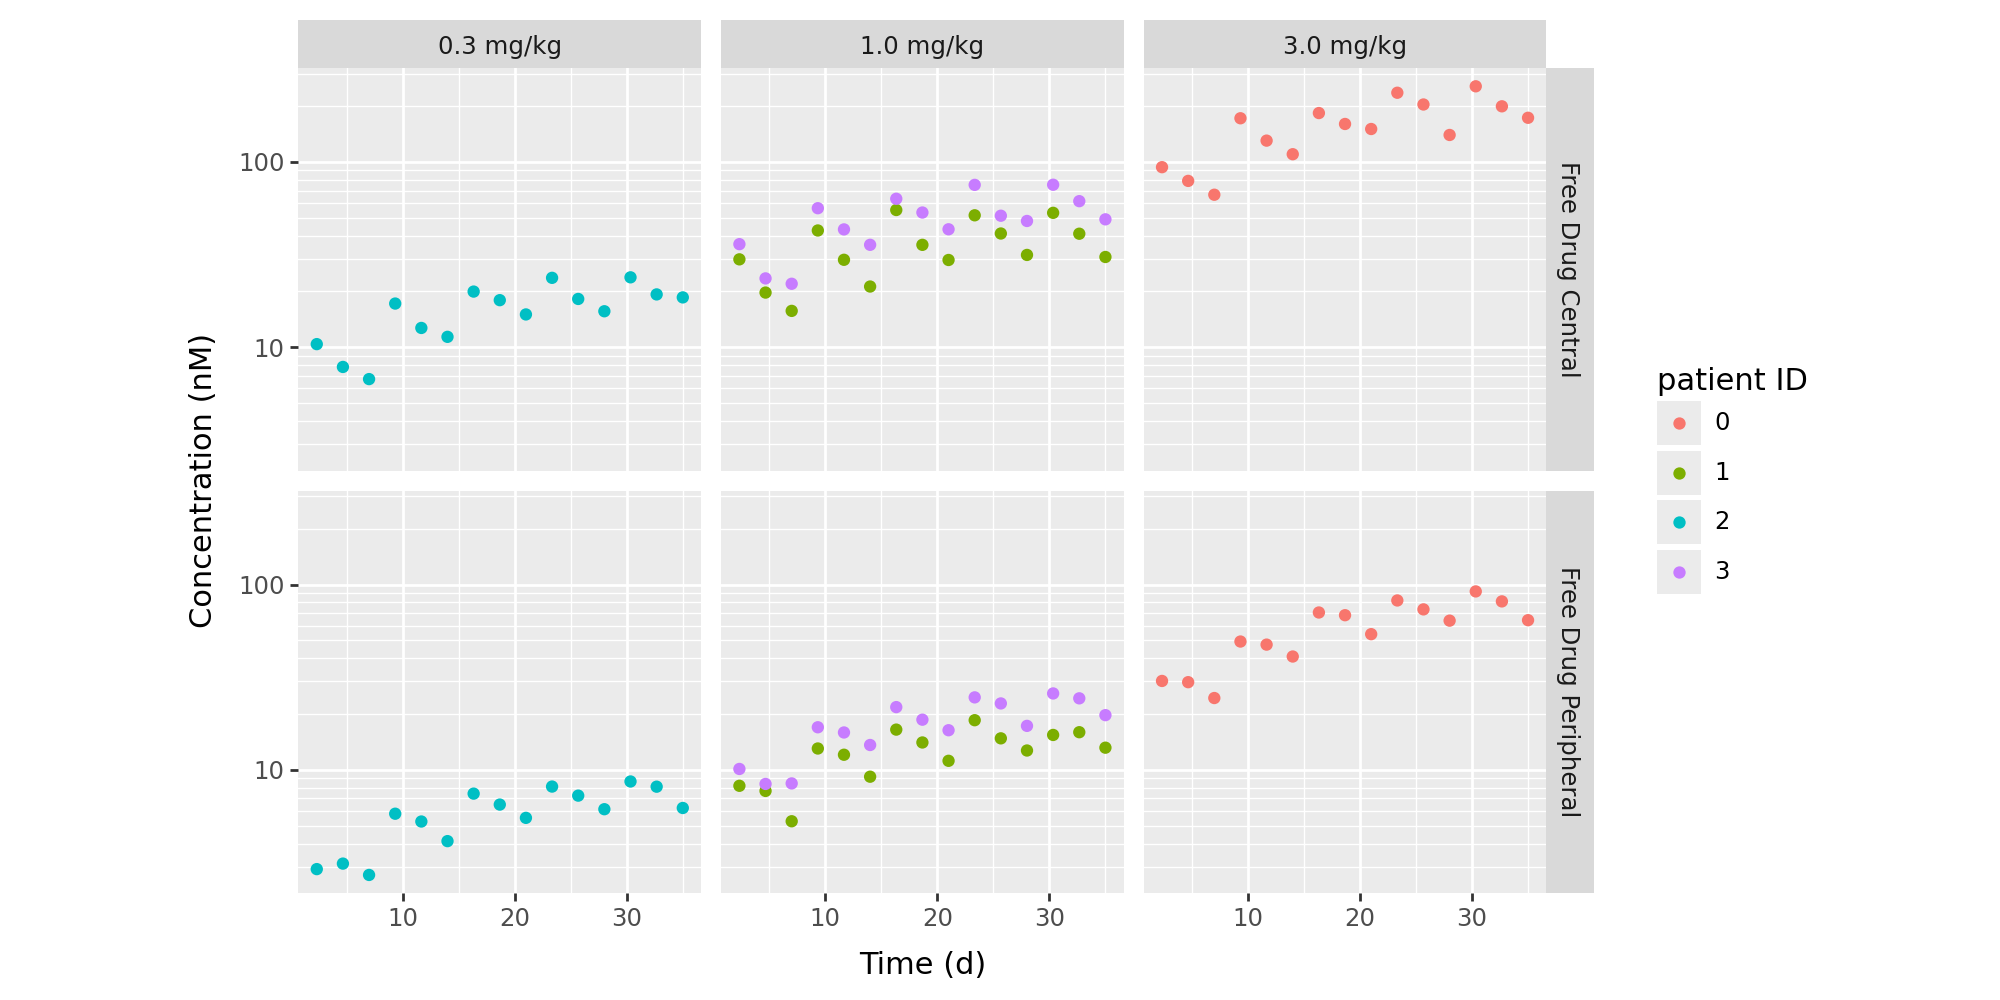

In [6]:
fig = (ggplot()
       + geom_point(data = Tdat, mapping = aes(x = 'time', y = 'measurement', color = 'factor(ID)'))
       + facet_grid('output_label ~ dose_label')
       + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
       + labs(y = 'Concentration (nM)', x = 'Time (d)', color = 'patient ID')
       + theme(aspect_ratio = 1, figure_size = (10,5))
      )

display(fig)

# Fit model to Data

In [7]:
Tpar_base = pd.read_csv('inputs/Parameters/Parameter.csv')
Tpar_base = pd.concat([Tpar_base,
                       pd.DataFrame({'parameter':['Dose_amt_IV','Dose_amt_SC']}).assign(unit = 'mg/kg',value = 0, is_fit = 'False')])

In [8]:
display(Tpar_base)

,parameter,unit,value,is_fit,upper_bound,lower_bound
0,Volume_c,L,3.000,False,NaN,NaN
1,Volume_p,L,13.000,False,NaN,NaN
2,MW,kDa,150.000,False,NaN,NaN
3,BW,kg,70.000,False,NaN,NaN
4,Pdist,1,0.300,False,NaN,NaN
5,Tdist,hr,7.000,False,NaN,NaN
6,Thalf,d,28.000,False,NaN,NaN
7,Receptors_c,nM,10.000,False,NaN,NaN
8,Receptors_p,nM,50.000,False,NaN,NaN
9,kon,1/nM/s,0.001,False,NaN,NaN


## Fit to all patients simultaneously

In [9]:
fit_par = ['Thalf', 'Pdist','Receptors_c', 'Receptors_p']
Tpar_prefit_joint = pd.concat([Tpar_base.query(f'not (parameter.isin({fit_par}))'),
                               Tpar_base.query(f'(parameter.isin({fit_par}))').assign(upper_bound = lambda x: x.value * 100,
                                                                                     lower_bound = lambda x: x.value / 100,
                                                                                     is_fit = True)])

In [10]:
display(Tpar_prefit_joint)

,parameter,unit,value,is_fit,upper_bound,lower_bound
0,Volume_c,L,3.000,False,NaN,NaN
1,Volume_p,L,13.000,False,NaN,NaN
2,MW,kDa,150.000,False,NaN,NaN
3,BW,kg,70.000,False,NaN,NaN
5,Tdist,hr,7.000,False,NaN,NaN
9,kon,1/nM/s,0.001,False,NaN,NaN
10,Thalf_R,hr,60.000,False,NaN,NaN
11,Kd,nM,90.000,False,NaN,NaN
12,F,1,0.750,False,NaN,NaN
13,Thalf_abs,hr,16.000,False,NaN,NaN


In [11]:
Tdos_joint  = Tdat[['dose_mpk', 'dose_route']].drop_duplicates().assign(route = lambda x: x.dose_route, times = str(list(range(0,35,7))), time_unit = 'd',
                                               amounts = lambda x: x.dose_mpk, amount_unit = 'mg/kg')

In [12]:
display(Tdos_joint)

,dose_mpk,dose_route,route,times,time_unit,amounts,amount_unit
0,3.0,Dose_SC,Dose_SC,"[0, 7, 14, 21, 28]",d,3.0,mg/kg
30,1.0,Dose_SC,Dose_SC,"[0, 7, 14, 21, 28]",d,1.0,mg/kg
60,0.3,Dose_SC,Dose_SC,"[0, 7, 14, 21, 28]",d,0.3,mg/kg


In [13]:
opt_joint = abm.optimize(measurements = Tdat,
             parameters = Tpar_prefit_joint,
             doses = Tdos_joint,
             models = 'inputs/Models/2compartment_Ab.iqd')

Total: 0, Running: 0, Succeeded: 0, Failed: 0

iteration,objective,Pdist_fit_12,Thalf_fit_13,Receptors_c_fit_14,Receptors_p_fit_15
0,140.676566,0.300000,28.000000,10.000000,50.000000
1,140.676566,0.300000,28.000000,10.000000,50.000000
2,140.676566,0.300000,28.000000,10.000000,50.000000
3,-29.953995,0.342824,27.773686,10.011226,50.543394
4,-97.122676,0.378521,29.046209,9.635911,47.288094
5,-97.122676,0.378521,29.046209,9.635911,47.288094
6,-103.758602,0.390479,28.838944,9.586067,47.537694
7,-106.625880,0.397657,28.869525,9.516379,46.288063
8,-107.693350,0.401524,28.200902,9.311841,46.352245
9,-109.147970,0.399702,27.449231,9.171376,45.808679


In [14]:
Tfit_joint = opt_joint.simulate(times = abm.linspace(0,35, 351,'d')).to_pandas(tall_outputs = True)


Tfit_joint['dose_label'] = Tfit_joint.apply(lambda x: str(x.dose_mpk) + ' mg/kg', axis = 1)
Tfit_joint['output_label'] = Tfit_joint.apply(lambda x: output_split(x.output), axis = 1)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

/home/jovyan/environment/.pixi/envs/default/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


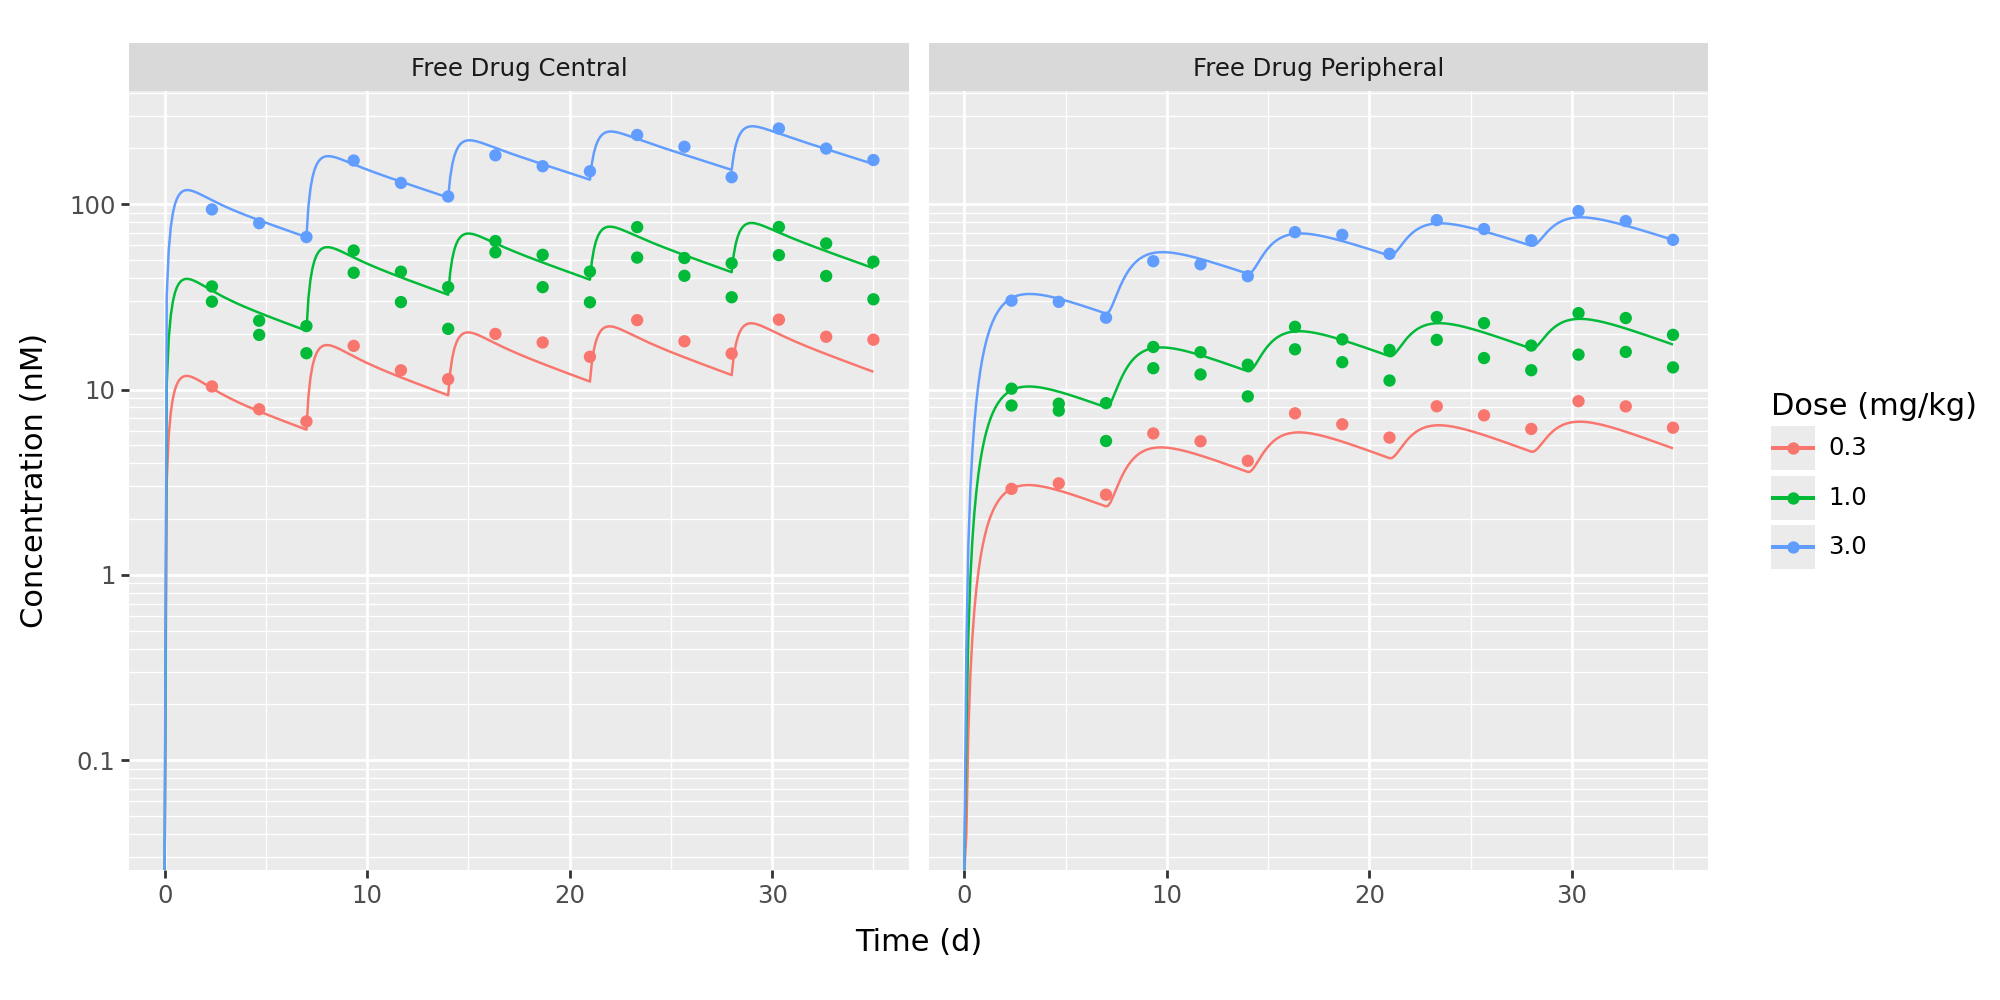

In [15]:
fig = (ggplot()
       + geom_point(data = Tdat, mapping = aes(x = 'time', y = 'measurement', color = 'factor(dose_mpk)'))
       + geom_line(data = Tfit_joint, mapping = aes(x = 't', y = 'value', color = 'factor(dose_mpk)'))
       + facet_wrap('output_label')
       + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
       + labs(y = 'Concentration (nM)', x = 'Time (d)', color = 'Dose (mg/kg)')
       + theme(aspect_ratio = 1, figure_size = (10,5))
      )

display(fig)

In [16]:
Tpar_fit_joint = opt_joint.fit_parameter_table.to_pandas()
display(Tpar_fit_joint)

,parameter,unit,value,is_fit,upper_bound,lower_bound,global_parameter_name
0,Volume_c,L,3.000000,False,NaN,NaN,Volume_c_fit_0
1,Volume_p,L,13.000000,False,NaN,NaN,Volume_p_fit_1
2,MW,kDa,150.000000,False,NaN,NaN,MW_fit_2
3,BW,kg,70.000000,False,NaN,NaN,BW_fit_3
4,Tdist,hr,7.000000,False,NaN,NaN,Tdist_fit_4
5,kon,1/nM/s,0.001000,False,NaN,NaN,kon_fit_5
6,Thalf_R,hr,60.000000,False,NaN,NaN,Thalf_R_fit_6
7,Kd,nM,90.000000,False,NaN,NaN,Kd_fit_7
8,F,1,0.750000,False,NaN,NaN,F_fit_8
9,Thalf_abs,hr,16.000000,False,NaN,NaN,Thalf_abs_fit_9


## Fit individual patients

In [17]:
fit_same = ['Thalf','Pdist']
fit_diff = ['Receptors_c', 'Receptors_p']
ID_list = [0,1,2,3]

Tpar_prefit_ind = pd.concat([Tpar_base.query(f'not ((parameter.isin({fit_same})) or (parameter.isin({fit_diff})))').assign(ID = '*'),
                         Tpar_base.query(f'parameter.isin({fit_same})').assign(ID = '*', upper_bound = lambda x: x.value * 100,
                                                                          lower_bound = lambda x: x.value /100, is_fit = True),
                         pd.concat([Tpar_base.query(f'parameter.isin({fit_diff})').assign(ID = i, upper_bound = lambda x: x.value * 100,
                                                                          lower_bound = lambda x: x.value /100, is_fit = True)\
                                    for i in ID_list])
                        ])

In [18]:
display(Tpar_prefit_ind)

,parameter,unit,value,is_fit,upper_bound,lower_bound,ID
0,Volume_c,L,3.000,False,NaN,NaN,*
1,Volume_p,L,13.000,False,NaN,NaN,*
2,MW,kDa,150.000,False,NaN,NaN,*
3,BW,kg,70.000,False,NaN,NaN,*
5,Tdist,hr,7.000,False,NaN,NaN,*
9,kon,1/nM/s,0.001,False,NaN,NaN,*
10,Thalf_R,hr,60.000,False,NaN,NaN,*
11,Kd,nM,90.000,False,NaN,NaN,*
12,F,1,0.750,False,NaN,NaN,*
13,Thalf_abs,hr,16.000,False,NaN,NaN,*


In [19]:
Tdos_ind  = Tdat[['dose_mpk', 'ID', 'dose_route']].drop_duplicates().assign(route = lambda x: x.dose_route, times = str(list(range(0,35,7))), time_unit = 'd',
                                               amounts = lambda x: x.dose_mpk, amount_unit = 'mg/kg')

In [20]:
display(Tdos_ind)

,dose_mpk,ID,dose_route,route,times,time_unit,amounts,amount_unit
0,3.0,0,Dose_SC,Dose_SC,"[0, 7, 14, 21, 28]",d,3.0,mg/kg
30,1.0,1,Dose_SC,Dose_SC,"[0, 7, 14, 21, 28]",d,1.0,mg/kg
60,0.3,2,Dose_SC,Dose_SC,"[0, 7, 14, 21, 28]",d,0.3,mg/kg
90,1.0,3,Dose_SC,Dose_SC,"[0, 7, 14, 21, 28]",d,1.0,mg/kg


In [21]:
opt_ind = abm.optimize(measurements = Tdat,
             parameters = Tpar_prefit_ind,
             doses = Tdos_ind,
             models = 'inputs/Models/2compartment_Ab.iqd')

Total: 0, Running: 0, Succeeded: 0, Failed: 0

iteration,objective,Receptors_c_fit_14,Receptors_p_fit_15,Pdist_fit_12,Thalf_fit_13,Receptors_c_fit_16,Receptors_p_fit_17,Receptors_c_fit_18,Receptors_p_fit_19,Receptors_c_fit_20,Receptors_p_fit_21
0,140.676566,10.000000,50.000000,0.300000,28.000000,10.000000,50.000000,10.000000,50.000000,10.000000,50.000000
1,140.676566,10.000000,50.000000,0.300000,28.000000,10.000000,50.000000,10.000000,50.000000,10.000000,50.000000
2,-216.810994,10.065462,51.717676,0.466072,27.185772,10.367382,63.065446,9.688326,41.700894,9.920627,47.574013
3,-451.487014,9.616257,47.350842,0.363274,30.625098,13.683278,80.707270,8.758743,35.049252,9.186236,41.638660
4,-489.540615,10.414477,53.940878,0.429600,43.809804,12.279300,66.847419,7.585733,29.056171,9.468194,43.162418
5,-511.506751,10.621252,57.367779,0.403152,42.354491,12.431809,71.985519,7.632560,30.485940,9.565654,44.377688
6,-511.506751,10.621252,57.367779,0.403152,42.354491,12.431809,71.985519,7.632560,30.485940,9.565654,44.377688
7,-517.230813,10.576233,55.191821,0.411304,41.962520,12.484323,74.111129,7.685899,31.726098,9.579532,44.825175
8,-517.230813,10.576233,55.191821,0.411304,41.962520,12.484323,74.111129,7.685899,31.726098,9.579532,44.825175
9,-518.665232,10.561366,54.887193,0.405474,41.950347,12.489907,73.813047,7.700351,31.920240,9.570337,44.725987


In [22]:
Tfit_ind = opt_ind.simulate(times = abm.linspace(0,35, 351,'d')).to_pandas(tall_outputs = True)


Tfit_ind['dose_label'] = Tfit_ind.apply(lambda x: str(x.dose_mpk) + ' mg/kg', axis = 1)
Tfit_ind['output_label'] = Tfit_ind.apply(lambda x: output_split(x.output), axis = 1)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

/home/jovyan/environment/.pixi/envs/default/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10


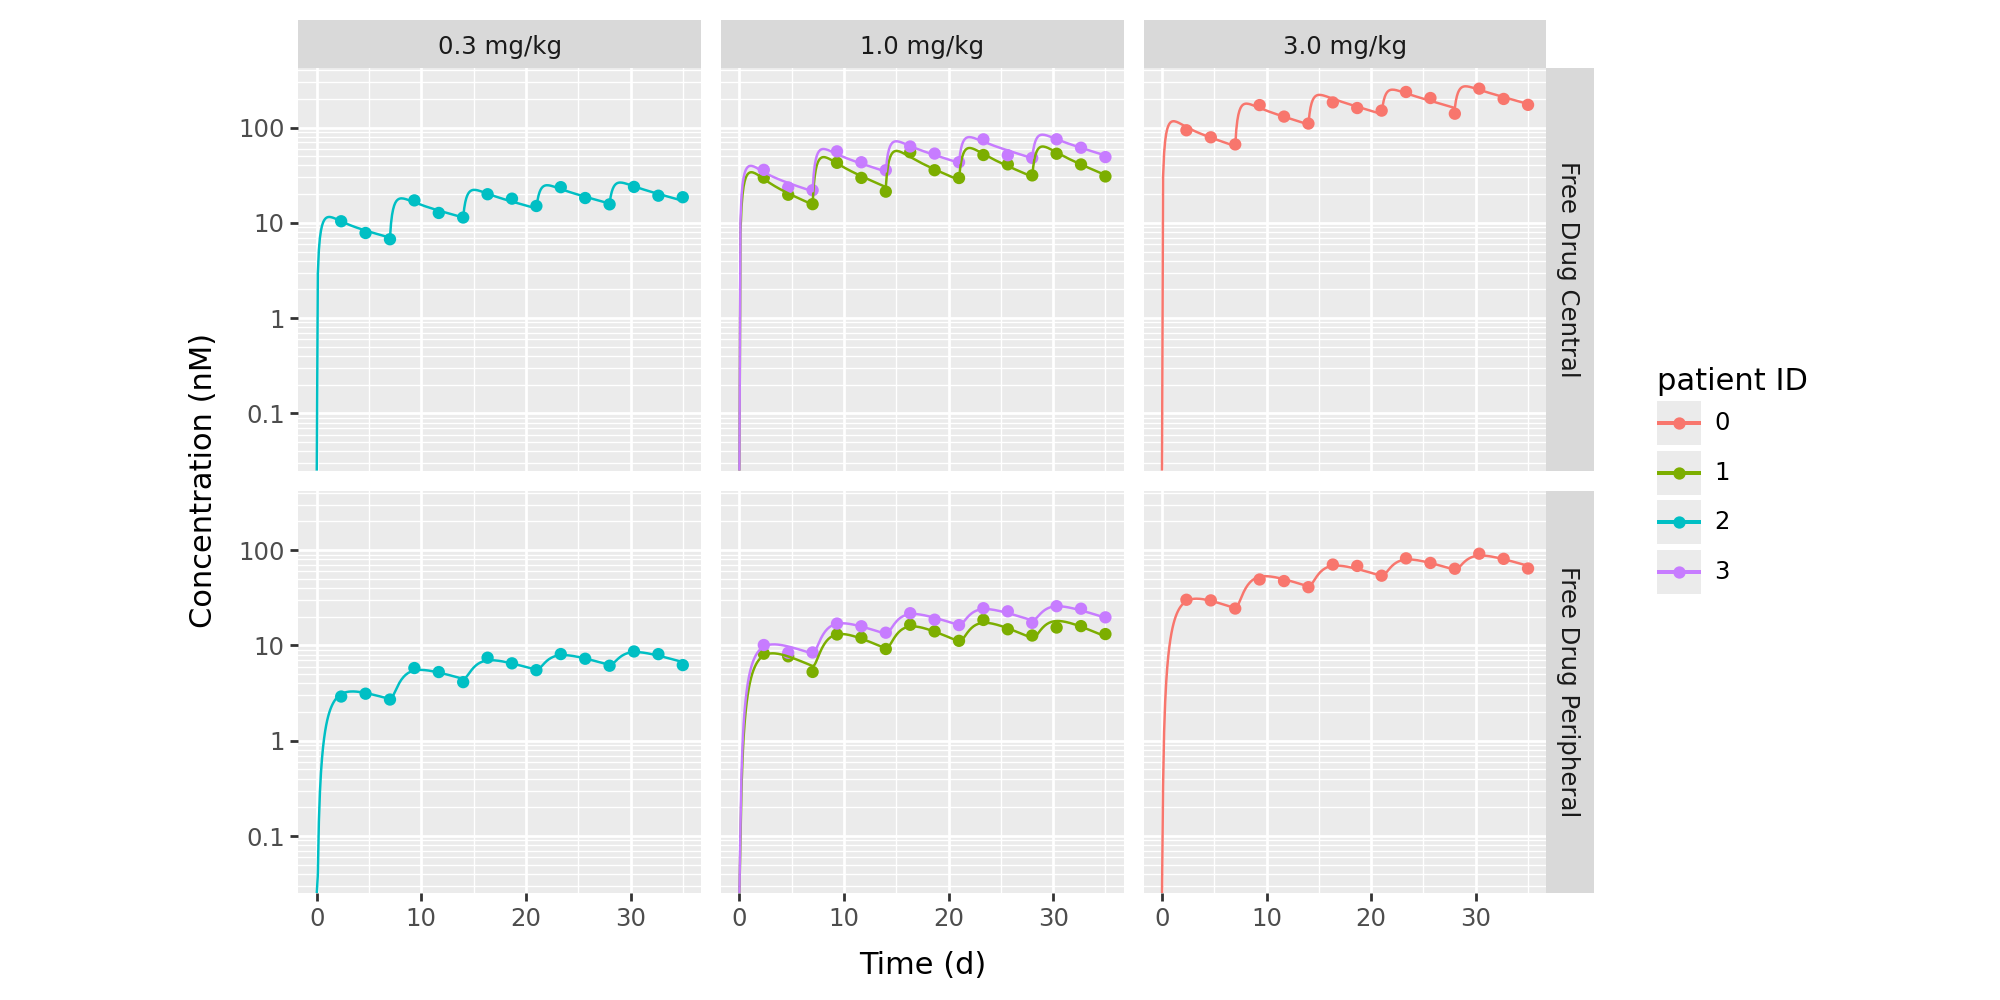

In [23]:
fig = (ggplot()
       + geom_point(data = Tdat, mapping = aes(x = 'time', y = 'measurement', color = 'factor(ID)'))
       + geom_line(data = Tfit_ind, mapping = aes(x = 't', y = 'value', color = 'factor(ID)'))
       + facet_grid('output_label ~ dose_label')
       + scale_y_log10(breaks = 10.**np.arange(-20,20,1))
       + labs(y = 'Concentration (nM)', x = 'Time (d)', color = 'patient ID')
       + theme(aspect_ratio = 1, figure_size = (10,5))
      )

display(fig)

In [24]:
Tpar_fit_ind = opt_ind.fit_parameter_table.to_pandas()
display(Tpar_fit_ind)

,parameter,unit,value,is_fit,upper_bound,lower_bound,ID,global_parameter_name
0,Volume_c,L,3.000000,False,NaN,NaN,*,Volume_c_fit_0
1,Volume_p,L,13.000000,False,NaN,NaN,*,Volume_p_fit_1
2,MW,kDa,150.000000,False,NaN,NaN,*,MW_fit_2
3,BW,kg,70.000000,False,NaN,NaN,*,BW_fit_3
4,Tdist,hr,7.000000,False,NaN,NaN,*,Tdist_fit_4
5,kon,1/nM/s,0.001000,False,NaN,NaN,*,kon_fit_5
6,Thalf_R,hr,60.000000,False,NaN,NaN,*,Thalf_R_fit_6
7,Kd,nM,90.000000,False,NaN,NaN,*,Kd_fit_7
8,F,1,0.750000,False,NaN,NaN,*,F_fit_8
9,Thalf_abs,hr,16.000000,False,NaN,NaN,*,Thalf_abs_fit_9


# Save fitted parameter tables

In [25]:
Tpar_fit_ind.to_csv('Par_fit_ind.csv', index = False)
Tpar_fit_joint.to_csv('Tpar_fit_joint.csv', index = False)